## ModClark Parameters Optimization

This notebook details the process for optimizing the ModClark Instantaneous Unit Hydrograph (IUH) parameters, $T_c$ and $R$. The optimization methodology adheres to the principles outlined in [the main documentation](../../README.MD).

During the precipitation data preprocessing, an ambiguity arose regarding the time standard (UTC vs. local time) of the input data. To address this, two distinct preprocessed datasets were generated: one assuming UTC timestamps and another assuming local time. The local time definition was derived from the precipitation station metadata, which includes a UTC offset column.

---

Prior to optimizing parameters for all selected storm events, a preliminary analysis will be conducted. A subset of 10 randomly selected events from 30 random watersheds will be optimized using both the UTC and local time datasets. The dataset yielding a superior average Nash-Sutcliffe Efficiency (NSE) will be adopted as the correct time standard for subsequent optimizations.

Initial observations suggest that the precipitation data is more likely recorded in local time. This is indicated by a noticeable delay in the hydrological response when the UTC precipitation dataset is used. The comparative average NSE values for each dataset will ultimately determine which dataset is utilized for the full optimization.

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import sys
from tqdm.notebook import tqdm
from pysheds.grid import Grid
from matplotlib import pyplot as plt
import os
from time import sleep

In [2]:
# Custom ModulesPath.cwd().parent.parent
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

# from hydrology.modclark_model import ModClarkModel
# from utils.data_utils import glimpse
# from plotting_functions.hydrograph import *

### Load and Analyze Storm Events Metada
#### UTC Time Standard

In [3]:
# Load events metadata
events_metadata_utc_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events.parquet'
storm_events_utc_metadata = pd.read_parquet(events_metadata_utc_path)

In [4]:
# Analyze storm events metadata
# glimpse(storm_events_utc_metadata)

In [5]:
print(f"\nTotal number of storm events: {len(storm_events_utc_metadata)}")
storm_events_utc_metadata['ws_id'] = storm_events_utc_metadata['storm_id'].str.split('_').str[0]
unique_watersheds = storm_events_utc_metadata['ws_id'].unique()
print(f"Number of unique watersheds: {len(unique_watersheds)}")
print(f"\nDistribution of storm events per watershed:")
print(storm_events_utc_metadata.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))
avg_events_per_watershed = storm_events_utc_metadata.groupby('ws_id').size().mean()
print(f"\nNumber of watersheds with less than 10 storm events: {storm_events_utc_metadata.groupby('ws_id').size()[storm_events_utc_metadata.groupby('ws_id').size() < 10].count()}")
print(f"Number of watersheds with less than 5 storm events: {storm_events_utc_metadata.groupby('ws_id').size()[storm_events_utc_metadata.groupby('ws_id').size() < 5].count()}")
print(f"Average response time (in minutes): {storm_events_utc_metadata['response_min'].mean():.2f}")
print(f"Average precipitation duration (in minutes): {storm_events_utc_metadata['ppt_dutation_min'].mean():.2f}")
print(f"Number of storm events with response time > 60 minutes: {storm_events_utc_metadata[storm_events_utc_metadata['response_min'] > 60].shape[0]}")
print(f"Number of watershed with response time > 60 minutes: {storm_events_utc_metadata[storm_events_utc_metadata['response_min'] > 60]['ws_id'].nunique()}")
print(f"Number of storm watersheds with response time no more than 30 minutes: {storm_events_utc_metadata[storm_events_utc_metadata['response_min'] <= 30]['ws_id'].nunique()}")
print(f"Number of watersheds with more than 1 precipitation station: {storm_events_utc_metadata[storm_events_utc_metadata['n_ppt_stations'] > 1]['ws_id'].nunique()}")
print(f"Number of storm events with no precipitation after peakflow: {storm_events_utc_metadata[storm_events_utc_metadata['total_ppt_after_peak_mm'] == 0].shape[0]}")
print(f"Number of watersheds  with no precipitation after peakflow: {storm_events_utc_metadata[storm_events_utc_metadata['total_ppt_after_peak_mm'] == 0]['ws_id'].nunique()}")

print(f"""
Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time <= 30 minutes
    - Total precipitation after peakflow = 0 mm
      """)
filtered_storm_events_utc_metada = storm_events_utc_metadata[(storm_events_utc_metadata['response_min'] <= 30) & 
                                             (storm_events_utc_metadata['total_ppt_after_peak_mm'] == 0)]
filtered_storm_events_utc_metada = filtered_storm_events_utc_metada.groupby('ws_id').filter(lambda x: len(x) >= 5)
print(filtered_storm_events_utc_metada.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))

print(f"\nNumber of storm events that follow the criteria: {len(filtered_storm_events_utc_metada)}")




Total number of storm events: 62258
Number of unique watersheds: 461

Distribution of storm events per watershed:
count    461.0
mean     135.0
std      107.0
min        2.0
25%       57.0
50%      109.0
75%      190.0
max      571.0
Name: event_count, dtype: float64

Number of watersheds with less than 10 storm events: 17
Number of watersheds with less than 5 storm events: 7
Average response time (in minutes): 69.18
Average precipitation duration (in minutes): 1923.81
Number of storm events with response time > 60 minutes: 608
Number of watershed with response time > 60 minutes: 191
Number of storm watersheds with response time no more than 30 minutes: 437
Number of watersheds with more than 1 precipitation station: 83
Number of storm events with no precipitation after peakflow: 18557
Number of watersheds  with no precipitation after peakflow: 456

Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time

#### Local Time Standard

In [6]:
# Load events metadata
events_metadata_tz_offset_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events_tz_offset.parquet'
storm_events_tz_offset_metadata = pd.read_parquet(events_metadata_tz_offset_path)

In [7]:
print(f"\nTotal number of storm events: {len(storm_events_tz_offset_metadata)}")
storm_events_tz_offset_metadata['ws_id'] = storm_events_tz_offset_metadata['storm_id'].str.split('_').str[0]
unique_watersheds = storm_events_tz_offset_metadata['ws_id'].unique()
print(f"Number of unique watersheds: {len(unique_watersheds)}")
print(f"\nDistribution of storm events per watershed:")
print(storm_events_tz_offset_metadata.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))
avg_events_per_watershed = storm_events_tz_offset_metadata.groupby('ws_id').size().mean()
print(f"\nNumber of watersheds with less than 10 storm events: {storm_events_tz_offset_metadata.groupby('ws_id').size()[storm_events_tz_offset_metadata.groupby('ws_id').size() < 10].count()}")
print(f"Number of watersheds with less than 5 storm events: {storm_events_tz_offset_metadata.groupby('ws_id').size()[storm_events_tz_offset_metadata.groupby('ws_id').size() < 5].count()}")
print(f"Average response time (in minutes): {storm_events_tz_offset_metadata['response_min'].mean():.2f}")
print(f"Average precipitation duration (in minutes): {storm_events_tz_offset_metadata['ppt_dutation_min'].mean():.2f}")
print(f"Number of storm events with response time > 60 minutes: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['response_min'] > 60].shape[0]}")
print(f"Number of watershed with response time > 60 minutes: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['response_min'] > 60]['ws_id'].nunique()}")
print(f"Number of storm watersheds with response time no more than 30 minutes: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['response_min'] <= 30]['ws_id'].nunique()}")
print(f"Number of watersheds with more than 1 precipitation station: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['n_ppt_stations'] > 1]['ws_id'].nunique()}")
print(f"Number of storm events with no precipitation after peakflow: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['total_ppt_after_peak_mm'] == 0].shape[0]}")
print(f"Number of watersheds  with no precipitation after peakflow: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['total_ppt_after_peak_mm'] == 0]['ws_id'].nunique()}")

print(f"""
Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time <= 30 minutes
    - Total precipitation after peakflow = 0 mm
      """)
filtered_storm_events_tz_offset_metada = storm_events_tz_offset_metadata[(storm_events_tz_offset_metadata['response_min'] <= 30) & 
                                             (storm_events_tz_offset_metadata['total_ppt_after_peak_mm'] == 0)]
filtered_storm_events_tz_offset_metada = filtered_storm_events_tz_offset_metada.groupby('ws_id').filter(lambda x: len(x) >= 5)
print(filtered_storm_events_tz_offset_metada.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))

print(f"\nNumber of storm events that follow the criteria: {len(filtered_storm_events_tz_offset_metada)}")




Total number of storm events: 81672
Number of unique watersheds: 461

Distribution of storm events per watershed:
count    461.0
mean     177.0
std      132.0
min        4.0
25%       75.0
50%      150.0
75%      254.0
max      709.0
Name: event_count, dtype: float64

Number of watersheds with less than 10 storm events: 12
Number of watersheds with less than 5 storm events: 3
Average response time (in minutes): 89.48
Average precipitation duration (in minutes): 1906.67
Number of storm events with response time > 60 minutes: 954
Number of watershed with response time > 60 minutes: 251
Number of storm watersheds with response time no more than 30 minutes: 439
Number of watersheds with more than 1 precipitation station: 83
Number of storm events with no precipitation after peakflow: 21904
Number of watersheds  with no precipitation after peakflow: 456

Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time

To reduce computational demand, storm events that did not meet specific quality criteria were excluded from the modeling process. The exclusion criteria were as follows:

1.  **No precipitation after peak flow:** This criterion ensures more uniform hydrograph shapes, indicating a clearer single-event response.
2.  **Response time less than or equal to 30 minutes:** A 30-minute threshold is considered a reasonable minimum for a watershed's hydrological response. Events with a response time greater than 30 minutes were likely indicative of data misalignment or spatial variability not adequately captured by the precipitation stations.
3.  **Watersheds with fewer than 5 storm events:** After applying the first two criteria, watersheds with an insufficient number of remaining storm events (fewer than 5) were also excluded from the study.

This filtering process significantly reduced the dataset size: the total number of events to optimize decreased from **62,200 to 17,200** for the UTC dataset and from **81,600 para 20,200**. However, the number of watersheds also decreased, from **461 to 406** for UTC dataset and to **412** for Local Time dataset. 


### Preprocessing

The ModClarks IUH, requires a distance to outlet grid, to compute the time area histogram. The code in this section computes the distance to outlet for each watershed and saves it locally for using it during the modeling process. 

In [8]:
# Define functions

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.warp
from pathlib import Path
from tqdm import tqdm
from shapely import wkt
from pysheds.grid import Grid

# --- Constants ---
D8_DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

# --- Helper Functions (Moved from main script) ---

def create_distance_weights(resolution: float, fdir: np.ndarray) -> np.ndarray:
    """Creates a weights grid for calculating geometric distance in pysheds."""
    cardinal_dirs = (64, 1, 4, 16)
    diagonal_dirs = (128, 2, 8, 32)
    cardinal_dist = resolution
    diagonal_dist = np.sqrt(2) * resolution
    weights_grid = np.full_like(fdir, 0, dtype=np.float64)
    weights_grid[np.isin(fdir, cardinal_dirs)] = cardinal_dist
    weights_grid[np.isin(fdir, diagonal_dirs)] = diagonal_dist
    return weights_grid

def compute_distance_grid(grid: 'Grid', fdir: np.ndarray, resolution: float, pour_point: tuple) -> np.ndarray:
    """Computes a distance grid based on the flow direction grid."""
    x, y = pour_point
    weights = create_distance_weights(resolution, fdir)
    dist = grid.distance_to_outlet(
        x=x, y=y, fdir=fdir, dirmap=D8_DIRMAP, xytype='coordinate', weights=weights
    )
    return dist

def get_pour_point(vector_catch: gpd.GeoDataFrame) -> tuple[float, float]:
    """Extracts the pour point coordinates."""
    point_string = vector_catch['snapped_pour_point_nad83'].iloc[0]
    coordinates = wkt.loads(point_string)
    return (coordinates.x, coordinates.y)

def get_resolution_from_raster(ws_id: str, project_root_path: Path, target_crs: str) -> tuple[float, float]:
    """Gets the resolution of a flow direction raster."""
    flowdir_path = project_root_path / f"data/silver/geo/raster/watersheds/flowdir_{ws_id}.tif"
    with rasterio.open(flowdir_path) as src:
        transform, _, _ = rasterio.warp.calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
    return (transform[0], transform[4])

# --- Main Preprocessing Function ---

def preprocess_and_save_distance_grid(ws_id: str, project_root: Path, display=False):
    """
    Computes and saves the distance-to-outlet grid for a watershed as a .npy file.
    """
    if display:
        print(f"Preprocessing distance grid for watershed: {ws_id}...")
    try:
        # Define I/O paths
        ws_raster_dir = project_root / "data/silver/geo/raster/watersheds"
        ws_vector_dir = project_root / 'data/silver/geo/gpkg/watersheds'
        output_dir = project_root / "data/gold/geo/raster/watersheds"
        output_dir.mkdir(parents=True, exist_ok=True) # Ensure output directory exists

        flowdir_path = ws_raster_dir / f"flowdir_{ws_id}.tif"
        ws_mask_path = ws_raster_dir / f"catchment_{ws_id}.tif"
        vector_catch_path = ws_vector_dir / f'catchment_{ws_id}.gpkg'
        output_path = output_dir / f"distance_grid_{ws_id}.npy"

        # 1. Load necessary geo-data
        vector_catch = gpd.read_file(vector_catch_path)
        grid = Grid.from_raster(str(flowdir_path), data_name='flowdir')
        fdir = grid.read_raster(str(flowdir_path), dtype=np.float32)
        catch_mask = grid.read_raster(str(ws_mask_path), dtype=np.float32)
        grid.clip_to(catch_mask)

        # 2. Get parameters for distance calculation
        pour_point = get_pour_point(vector_catch)
        target_crs = vector_catch.crs
        x_res, _ = get_resolution_from_raster(ws_id, project_root, target_crs)
        resolution_m = abs(x_res)

        # 3. Compute the distance grid
        distance_grid = compute_distance_grid(grid, fdir, resolution_m, pour_point)

        # 4. Save the final grid as a .npy file
        np.save(output_path, distance_grid)
        if display:
            print(f"  -> Successfully saved to {output_path}")

    except Exception as e:
        print(f"  -> ERROR: Failed to preprocess {ws_id}: {e}")

if __name__ == '__main__':
    # --- Setup ---
    # Define the project root and output directory
    output_dir = PROJECT_ROOT / "data/gold/geo/raster/watersheds"
    
    # Ensure the output directory exists
    output_dir.mkdir(parents=True, exist_ok=True)

    # --- 1. Get a list of all watershed IDs that need processing ---
    utc_metadata_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events.parquet'
    utc_metadata = pd.read_parquet(utc_metadata_path)
    utc_metadata['ws_id'] = utc_metadata['storm_id'].str.split('_').str[0]
    all_watershed_ids = utc_metadata['ws_id'].unique()

    # --- 2. Find watersheds that have already been processed ---
    # List files in the output directory and extract the ws_id from each filename
    processed_ws_ids = {
        f.replace('distance_grid_', '').replace('.npy', '') 
        for f in os.listdir(output_dir) if f.startswith('distance_grid_') and f.endswith('.npy')
    }

    # --- 3. Determine which watersheds to process now ---
    # Exclude the already processed watersheds from the main list
    ws_to_process = [ws_id for ws_id in all_watershed_ids if ws_id not in processed_ws_ids]

    print(f"Found {len(all_watershed_ids)} total watersheds.")
    print(f"Found {len(processed_ws_ids)} already processed grids. Skipping them.")
    print(f"--- Starting preprocessing for {len(ws_to_process)} remaining watersheds ---")

    # --- 4. Run preprocessing only on the remaining watersheds ---
    if ws_to_process:
        for ws_id in tqdm(ws_to_process, desc="Preprocessing Watersheds"):
            preprocess_and_save_distance_grid(ws_id, PROJECT_ROOT)
            sleep(0.5)

    
    print("--- Preprocessing Complete ---")

Found 461 total watersheds.
Found 33 already processed grids. Skipping them.
--- Starting preprocessing for 428 remaining watersheds ---


Preprocessing Watersheds:   0%|          | 0/428 [00:00<?, ?it/s]

: 

In [ ]:
# Import necessary libraries...
# (np, pd, gpd, Path, tqdm, Grid, etc.)

# --- Constants ---
D8_DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

# --- Function Definitions ---

def select_n_random_watersheds(...):
    # This function remains unchanged
    # ...

def load_files(ws_id: str, project_root_path: Path, tz_offset: bool = False) -> tuple:
    # This function remains mostly unchanged, but no longer needs to return grid/fdir for the main loop
    # ...
    grid = Grid.from_raster(str(flowdir_path), data_name='flowdir')
    fdir = grid.read_raster(str(flowdir_path), dtype=np.float32) # Keep dtype fix
    catch_mask = grid.read_raster(str(ws_mask_path), dtype=np.float32) # Keep dtype fix
    grid.clip_to(catch_mask)
    return vector_catch, geo_characteristics, lined_up_data, grid, fdir

def get_resolution_from_raster(...):
    # This function remains unchanged
    # ...

def get_pour_point(...):
    # This function remains unchanged
    # ...

# --- NEW: Function to load pre-computed grid ---
def load_distance_grid(ws_id: str, project_root: Path) -> np.ndarray:
    """
    Loads a pre-computed distance grid from a .npy file.
    
    Args:
        ws_id: The watershed identifier.
        project_root: The root path of the project directory.

    Returns:
        A numpy array of the distance grid.
    
    Raises:
        FileNotFoundError: If the pre-computed file does not exist.
    """
    distance_grid_path = project_root / f"data/gold/geo/raster/watersheds/distance_grid_{ws_id}.npy"
    if not distance_grid_path.exists():
        raise FileNotFoundError(
            f"Distance grid not found: {distance_grid_path}. "
            "Please run the `preprocess_grids.py` script first."
        )
    return np.load(distance_grid_path)


# --- MODIFIED: Main comparison function ---
def compare_params_optimization(
    utc_metadata: pd.DataFrame,
    tz_offset_metadata: pd.DataFrame,
    project_root: Path,
    n_ws: int,
    n_ev: int,
    display: bool = True
) -> tuple[dict, dict]:
    """
    Compares Nash-Sutcliffe Efficiency (NSE) for watersheds from two datasets.
    """
    nse_utc_scores = {}
    nse_tz_offset_scores = {}
    delta_t = 900  # Time step in seconds

    storm_events_utc, storm_events_tz_offset = select_n_random_watersheds(
        utc_metadata, tz_offset_metadata, n_watersheds=n_ws, n_events=n_ev
    )
    ws_ids = storm_events_utc['ws_id'].unique()

    for ws_id in tqdm(ws_ids, desc="Processing watersheds"):
        if display:
            print(f"--- Processing Watershed: {ws_id} ---")

        nse_utc_scores[ws_id] = []
        nse_tz_offset_scores[ws_id] = []

        try:
            # Load hydrological data and vector file to get metadata
            vector_catch, _, lined_up_data_utc, _, _ = load_files(ws_id, project_root, tz_offset=False)
            _, _, lined_up_data_tz_offset, _, _ = load_files(ws_id, project_root, tz_offset=True)
            
            # Get necessary parameters
            target_crs = vector_catch.crs
            x_res, y_res = get_resolution_from_raster(ws_id, project_root, target_crs=target_crs)
            
            # --- CHANGE: Load the pre-computed grid instead of calculating it ---
            distance_grid = load_distance_grid(ws_id, project_root)
            cell_area = abs(x_res * y_res)
            
        except Exception as e:
            print(f"    Skipping watershed {ws_id} due to loading error: {e}")
            # Create dummy data to allow loops to run without crashing
            distance_grid = np.zeros((10, 10))
            cell_area = 900
            lined_up_data_utc = pd.DataFrame(index=pd.to_datetime([]))
            lined_up_data_tz_offset = pd.DataFrame(index=pd.to_datetime([]))
            
        # The optimization loops below remain exactly the same, as they
        # just require the `distance_grid` and `cell_area` variables.
        # ... (Loop for UTC data)
        # ... (Loop for Timezone-Offset data)
    
    return nse_utc_scores, nse_tz_offset_scores

# --- Example Usage (remains the same) ---
if __name__ == '__main__':
    # ... (Your main execution block)

### $R$ and $T_c$ Parameter Optimization
#### Compare sample watershed optmization between datasets

In [ ]:
# --- Imports ---
import random
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.warp
from shapely import wkt
# Assuming 'pysheds' and your custom 'ModClarkModel' are available in your environment.
# from pysheds.grid import Grid
# from custom_module import ModClarkModel

# --- Constants ---
# Using constants for values that don't change makes the code cleaner.
D8_DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32) # D8 flow direction mapping

# --- Function Definitions ---

def select_n_random_watersheds(
    dataset1: pd.DataFrame,
    dataset2: pd.DataFrame,
    n_watersheds: int = 30,
    n_events: int = 10
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selects a random sample of watersheds and storm events from two metadata datasets.

    This function first filters both datasets to include only watersheds with a minimum
    number of events. Then, it randomly selects 'n_watersheds' and, for each of
    those, randomly selects 'n_events'.

    Args:
        dataset1: The first metadata DataFrame, containing 'ws_id' and 'storm_id'.
        dataset2: The second metadata DataFrame, with a similar structure to dataset1.
        n_watersheds: The number of unique watersheds to sample.
        n_events: The number of storm events to sample for each watershed.

    Returns:
        A tuple containing two DataFrames:
        - selected_events1: Sampled events from the first dataset.
        - selected_events2: Sampled events from the second dataset.
        
    Raises:
        ValueError: If a different number of watersheds are selected from the datasets
                    or if the requested number of watersheds is greater than available.
    """
    # Filter for watersheds with at least n_events
    ws_group1 = dataset1.groupby('ws_id')
    ws_group2 = dataset2.groupby('ws_id')
    dataset1_filtered = ws_group1.filter(lambda x: x['storm_id'].nunique() >= n_events)
    dataset2_filtered = ws_group2.filter(lambda x: x['storm_id'].nunique() >= n_events)

    # Find common watersheds after filtering
    unique_ws1 = set(dataset1_filtered['ws_id'].unique())
    unique_ws2 = set(dataset2_filtered['ws_id'].unique())
    common_ws_ids = list(unique_ws1.intersection(unique_ws2))

    if n_watersheds > len(common_ws_ids):
        raise ValueError(
            f"Requested {n_watersheds} watersheds, but only {len(common_ws_ids)} "
            f"are available in both datasets with at least {n_events} events."
        )

    # Sample from the common watersheds
    sampled_ws_ids = random.sample(common_ws_ids, n_watersheds)

    sampled_df1 = dataset1[dataset1['ws_id'].isin(sampled_ws_ids)].copy()
    sampled_df2 = dataset2[dataset2['ws_id'].isin(sampled_ws_ids)].copy()

    # It's good practice to double-check that the filtered sets are equal
    if len(sampled_df1['ws_id'].unique()) != len(sampled_df2['ws_id'].unique()):
        raise ValueError("A different number of watersheds was selected between datasets.")

    # Group by watershed and sample n_events for each
    selected_events1 = (
        sampled_df1.groupby('ws_id')['storm_id']
        .apply(lambda x: x.drop_duplicates().sample(n=n_events, random_state=42))
        .reset_index()
    )
    selected_events2 = (
        sampled_df2.groupby('ws_id')['storm_id']
        .apply(lambda x: x.drop_duplicates().sample(n=n_events, random_state=42))
        .reset_index()
    )

    # Merge back to get other event data like start/end times
    event_cols = ['storm_id', 'event_start', 'event_end']
    selected_events1 = selected_events1.merge(
        dataset1[event_cols].drop_duplicates(), on='storm_id'
    )
    selected_events2 = selected_events2.merge(
        dataset2[event_cols].drop_duplicates(), on='storm_id'
    )

    return selected_events1, selected_events2


def load_files(
    ws_id: str,
    project_root_path: Path,
    tz_offset: bool = False
) -> tuple:
    """
    Loads all necessary vector, raster, and tabular files for a given watershed.

    Args:
        ws_id: The watershed identifier.
        project_root_path: The root path of the project directory (as a Path object).
        tz_offset: Boolean flag to load the timezone-offset hydrological data.

    Returns:
        A tuple containing:
        - vector_catch (GeoDataFrame)
        - geo_characteristics (DataFrame)
        - lined_up_data (DataFrame)
        - grid (pysheds.Grid instance)
        - fdir (numpy.ndarray of flow directions)
    """
    # Define folder paths from the project root
    ws_vector_dir = project_root_path / 'data/silver/geo/gpkg/watersheds'
    ws_raster_dir = project_root_path / "data/silver/geo/raster/watersheds"
    hydrological_data_dir = project_root_path / 'data/gold/tabular/lined_up_data'

    # Define file paths
    ws_mask_path = ws_raster_dir / f"catchment_{ws_id}.tif"
    flowdir_path = ws_raster_dir / f"flowdir_{ws_id}.tif"
    vector_catch_path = ws_vector_dir / f'catchment_{ws_id}.gpkg'
    geo_characteristics_path = project_root_path / 'data/gold/tabular/geomorphological_characteristics.csv'
    
    if tz_offset:
        lined_up_data_path = hydrological_data_dir / f'ws_{ws_id}_tz_offset.parquet'
    else:
        lined_up_data_path = hydrological_data_dir / f'ws_{ws_id}.parquet'

    # Load vector files
    vector_catch = gpd.read_file(vector_catch_path)

    # Load tabular data
    geo_characteristics = pd.read_csv(geo_characteristics_path, dtype={'Station ID': str})
    lined_up_data = pd.read_parquet(lined_up_data_path)
    lined_up_data = lined_up_data.set_index('date').sort_index()

    # Load raster data using pysheds
    grid = Grid.from_raster(str(flowdir_path), data_name='flowdir')
    fdir = grid.read_raster(str(flowdir_path))
    catch_mask = grid.read_raster(str(ws_mask_path))
    grid.clip_to(catch_mask)

    return vector_catch, geo_characteristics, lined_up_data, grid, fdir


def create_distance_weights(resolution: float, fdir: np.ndarray) -> np.ndarray:
    """
    Creates a weights grid for calculating geometric distance in pysheds.

    This grid assigns a real-world distance to each cell based on its
    flow direction, accounting for longer diagonal paths.

    Args:
        resolution: The grid's cardinal resolution (cell width or height).
        fdir: The pysheds flow direction grid.

    Returns:
        A grid of weights representing the distance for each cell-to-cell link.
    """
    cardinal_dirs = (64, 1, 4, 16)
    diagonal_dirs = (128, 2, 8, 32)
    
    cardinal_dist = resolution
    diagonal_dist = np.sqrt(2) * resolution

    weights_grid = np.full_like(fdir, 0, dtype=np.float64)
    weights_grid[np.isin(fdir, cardinal_dirs)] = cardinal_dist
    weights_grid[np.isin(fdir, diagonal_dirs)] = diagonal_dist

    return weights_grid


def compute_distance_grid(grid: 'Grid', fdir: np.ndarray, resolution: float, pour_point: tuple) -> np.ndarray:
    """
    Computes a distance grid based on the flow direction grid.

    Args:
        grid: The pysheds Grid object, clipped to the catchment.
        fdir: The flow direction raster.
        resolution: The cell resolution (width/height) in the grid's units.
        pour_point: A tuple (x, y) of the outlet coordinates.

    Returns:
        A numpy array representing the distance from each cell to the outlet.
    """
    x, y = pour_point
    weights = create_distance_weights(resolution, fdir)
    dist = grid.distance_to_outlet(
         x=x, y=y, fdir=fdir, dirmap=D8_DIRMAP, xytype='coordinate', weights=weights
        )
    return dist


def get_resolution_from_raster(ws_id: str, project_root_path: Path, target_crs: str) -> tuple[float, float]:
    """
    Gets the resolution of a flow direction raster in the target CRS.

    Args:
        ws_id: The watershed identifier.
        project_root_path: The root path of the project directory.
        target_crs: The target Coordinate Reference System.

    Returns:
        A tuple of (x_resolution, y_resolution).
    """
    ws_raster_dir = project_root_path / "data/silver/geo/raster/watersheds"
    flowdir_path = ws_raster_dir / f"flowdir_{ws_id}.tif"

    with rasterio.open(flowdir_path) as src:
        transform, _, _ = rasterio.warp.calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
    # transform[0] is pixel width (x_res), transform[4] is pixel height (y_res)
    return (transform[0], transform[4])


def get_pour_point(vector_catch: gpd.GeoDataFrame) -> tuple[float, float]:
    """
    Extracts the pour point coordinates from the watershed vector file.

    Args:
        vector_catch: GeoDataFrame of the watershed.

    Returns:
        A tuple containing (x, y) coordinates of the pour point.
    """
    point_string = vector_catch['snapped_pour_point_nad83'].iloc[0]
    coordinates = wkt.loads(point_string)
    return (coordinates.x, coordinates.y)


def compare_params_optimization(
    utc_metadata: pd.DataFrame,
    tz_offset_metadata: pd.DataFrame,
    project_root: Path,
    n_ws: int,
    n_ev: int, 
    display: bool = True
) -> tuple[dict, dict]:
    """
    Compares Nash-Sutcliffe Efficiency (NSE) for watersheds from two datasets.

    This function orchestrates the entire workflow: selecting watersheds, loading
    data, preparing grids, and running a hydrological model optimization for
    both a UTC-based dataset and a timezone-offset dataset.

    Args:
        utc_metadata: Metadata for the UTC-based storm events.
        tz_offset_metadata: Metadata for the timezone-offset storm events.
        project_root: The root path of the project directory.
        n_ws: The number of watersheds to analyze.
        n_ev: The number of events per watershed to analyze.

    Returns:
        A tuple of two dictionaries: (nse_utc_scores, nse_tz_offset_scores).
        Each dictionary maps a ws_id to a list of NSE scores for that watershed.
    """
    nse_utc_scores = {}
    nse_tz_offset_scores = {}
    delta_t = 900  # Time step in seconds

    # 1. Select Watersheds and Events
    storm_events_utc, storm_events_tz_offset = select_n_random_watersheds(
        utc_metadata, tz_offset_metadata, n_watersheds=n_ws, n_events=n_ev
    )
    
    ws_ids = storm_events_utc['ws_id'].unique()

    # --- Main Loop: Process each watershed ---
    for ws_id in tqdm(ws_ids, desc="Processing watersheds"):
        if display:
            print(f"--- Processing Watershed: {ws_id} ---")
        
        # Initialize lists for the current watershed's scores
        nse_utc_scores[ws_id] = []
        nse_tz_offset_scores[ws_id] = []

        # 2. Load Data Files (placeholders used for missing files)
        try:
            vector_catch, _, lined_up_data_utc, grid, fdir = load_files(ws_id, project_root, tz_offset=False)
            _, _, lined_up_data_tz_offset, _, _ = load_files(ws_id, project_root, tz_offset=True)
            pour_point = get_pour_point(vector_catch)
            target_crs = vector_catch.crs
            x_res, y_res = get_resolution_from_raster(ws_id, project_root, target_crs=target_crs)
        except Exception as e:
            print(f"    Skipping watershed {ws_id} due to loading error: {e}")
            # Create dummy data to allow loops to run without crashing
            fdir = np.random.choice(D8_DIRMAP, size=(10, 10))
            pour_point = (0, 0)
            x_res, y_res = 30, -30
            lined_up_data_utc = pd.DataFrame(index=pd.to_datetime([]))
            lined_up_data_tz_offset = pd.DataFrame(index=pd.to_datetime([]))


        # 3. Prepare Grids and Parameters
        resolution_m = abs(x_res)
        cell_area = abs(x_res * y_res)
        distance_grid = compute_distance_grid(grid, fdir, resolution_m, pour_point)

        # --- 4a. Run Optimization for UTC data ---
        events_for_ws_utc = storm_events_utc[storm_events_utc['ws_id'] == ws_id]
        for _, row in events_for_ws_utc.iterrows():
            if display:
                print(f"  Running UTC event: {row['storm_id']}")
            df = lined_up_data_utc.loc[row['event_start']:row['event_end']].copy()
            
            model = ModClarkModel(df=df, distance_grid=distance_grid, cell_area=cell_area, delta_t=delta_t)
            optimized_params = model.run_optimization(display=False)
            nse_utc_scores[ws_id].append(optimized_params['nse'])

        # --- 4b. Run Optimization for Timezone-Offset data ---
        events_for_ws_tz = storm_events_tz_offset[storm_events_tz_offset['ws_id'] == ws_id]
        for _, row_tz in events_for_ws_tz.iterrows():
            if display:
                print(f"  Running TZ-Offset event: {row_tz['storm_id']}")
            df = lined_up_data_tz_offset.loc[row_tz['event_start']:row_tz['event_end']].copy()
            
            model = ModClarkModel(df=df, distance_grid=distance_grid, cell_area=cell_area, delta_t=delta_t)
            optimized_params = model.run_optimization(display=False)
            nse_tz_offset_scores[ws_id].append(optimized_params['nse'])

    return nse_utc_scores, nse_tz_offset_scores

# --- Example Usage ---
if __name__ == '__main__':
    # Define the root path to your project
    PROJECT_ROOT = Path.cwd().parent.parent

    try:

        # Run the comparison
        nse_utc_by_ws, nse_tz_by_ws = compare_params_optimization(
            utc_metadata=filtered_storm_events_utc_metada,
            tz_offset_metadata=filtered_storm_events_tz_offset_metada,
            project_root=PROJECT_ROOT,
            n_ws=30, # Number of watersheds to test
            n_ev=10,  # Number of events per watershed, 
            display=False
        )

        # --- Post-processing and Statistics ---
        # Flatten the dictionaries to get all scores for overall stats
        all_nse_utc = [score for scores_list in nse_utc_by_ws.values() for score in scores_list]
        all_nse_tz = [score for scores_list in nse_tz_by_ws.values() for score in scores_list]

        # Calculate Coefficient of Variation for each watershed
        cv_utc = []
        for ws_id, scores in nse_utc_by_ws.items():
            if scores and np.mean(scores) != 0:  # Avoid division by zero and handle empty lists
                cv = np.std(scores) / np.mean(scores)
                cv_utc.append(cv)

        cv_tz = []
        for ws_id, scores in nse_tz_by_ws.items():
            if scores and np.mean(scores) != 0: # Avoid division by zero and handle empty lists
                cv = np.std(scores) / np.mean(scores)
                cv_tz.append(cv)

        # --- Print Final Results ---
        print("\n--- Comparison Complete ---")
        # print(f"UTC NSE Scores (all events): {np.round(all_nse_utc, 3)}")
        # print(f"Timezone-Offset NSE Scores (all events): {np.round(all_nse_tz, 3)}")
        print(f"\nOverall Average UTC NSE: {np.mean(all_nse_utc):.3f}")
        print(f"Overall Average Timezone-Offset NSE: {np.mean(all_nse_tz):.3f}")
        
        # --- Average Coefficient of Variation ---
        if cv_utc:
             print(f"\nAverage Coefficient of Variation (UTC): {np.mean(cv_utc):.3f}")
        if cv_tz:
             print(f"Average Coefficient of Variation (Timezone-Offset): {np.mean(cv_tz):.3f}")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")


Processing watersheds:   0%|          | 0/30 [00:00<?, ?it/s]

: 

In [ ]:
def optmize_params_for_event(storm_medata: pd.core.series.Series,
                            vector_catch: gpd.GeoDataFrame,
                            geo_characteristics: pd.DataFrame,
                            lined_up_data: pd.DataFrame,
                            grid: Grid,
                            fdir: np.ndarray,
                            tz_offset: bool, 
                            use_geo_char: bool = False,
                            dynamic_ppt_loss_bounds: bool = False,
                            display: bool = False
                            ):
    """This function optimizes the ModClark model parameters for a given storm event."""
    wid = storm_medata['ws_id']
    delta_t=900
        
    df = lined_up_data.loc[storm_medata['event_start']:storm_medata['event_end']].copy()
    
    if use_geo_char:        
        basin_length = geo_characteristics.loc[geo_characteristics['Station ID'] == wid, 'Basin Length'].values[0]
        slope_10_85 = geo_characteristics.loc[geo_characteristics['Station ID'] == wid, 'Flowpath 10-85 Slope'].values[0]
        geo_char = (basin_length, slope_10_85)
    else:
        geo_char = None


    
    optmized_params = model.run_optimization(geo_char=geo_char, dynamic_ppt_loss_bounds=dynamic_ppt_loss_bounds, display=display)
    return optmized_params


pandas.core.series.Series

In [ ]:


# Compute weights for distance calculation (used to transform number of cell distance to meters)
resolution = get_projected_resolution(input_raster_path=sample_ws_flowdir_path, target_crs=vector_catch.crs)
avg_res = np.mean(np.abs(resolution))
weights = create_distance_weights(resolution=avg_res, fdir=fdir)

dist_meters = 

Text(0.5, 1.0, 'Flow Distance for watershed 03250322')

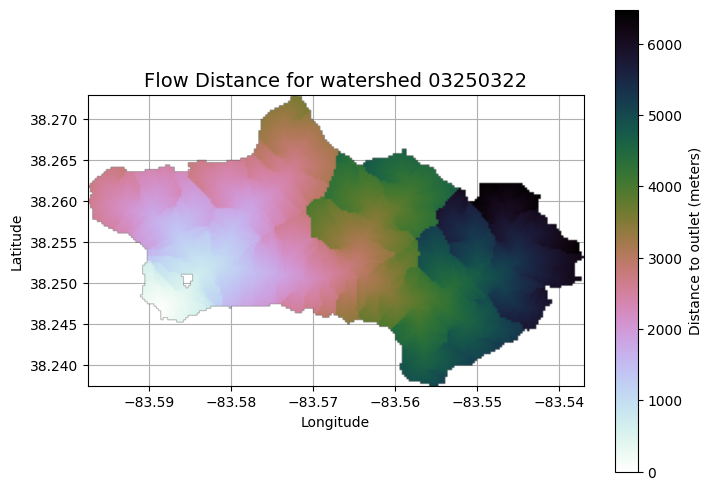

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)


ax.grid('on', zorder=0)
im = ax.imshow(dist_meters, extent=grid.extent, zorder=2,
                 cmap='cubehelix_r')
# Add a colorbar specific to the first axis
fig.colorbar(im, ax=ax, label='Distance to outlet (meters)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Flow Distance for watershed {sample_ws_id}', size=14)

# Ws id 03298150

In [ ]:

event_metada = filtered_storm_events_metada[filtered_storm_events_metada['ws_id'] == sample_ws_id]

In [448]:
# Define model parameters
# Choose the first event of selected watershed
event_metada_df = filtered_storm_events_metada[filtered_storm_events_metada['ws_id'] == sample_ws_id]
event_metada = event_metada_df.sample().iloc[0]
df = lined_up_data.loc[event_metada['event_start']:event_metada['event_end']].copy()
distance_grid = dist_meters.copy()
cell_area = avg_res**2
delta_t=15*30 

basin_length = geo_characteristics.loc[geo_characteristics['Station ID'] == sample_ws_id, 'Basin Length'].values[0]
slope_10_85 = geo_characteristics.loc[geo_characteristics['Station ID'] == sample_ws_id, 'Flowpath 10-85 Slope'].values[0]


In [449]:
model = ModClarkModel(df=df, distance_grid=distance_grid,cell_area=cell_area, delta_t=delta_t)

In [450]:
optmized_params_random_bounds = model.run_optimization()
optmized_params_computed_bounds = model.run_optimization(basin_length_m=basin_length, slope_10_85=slope_10_85)


--- 🚀 Starting Optimization ---
Using fixed, default search bounds.
differential_evolution step 1: f(x)= 2.0269066604374952
differential_evolution step 2: f(x)= 1.734008874554041
differential_evolution step 3: f(x)= 1.734008874554041
differential_evolution step 4: f(x)= 1.734008874554041
differential_evolution step 5: f(x)= 1.734008874554041
differential_evolution step 6: f(x)= 1.515097865918675
differential_evolution step 7: f(x)= 1.515097865918675
differential_evolution step 8: f(x)= 1.515097865918675
differential_evolution step 9: f(x)= 1.515097865918675
differential_evolution step 10: f(x)= 1.515097865918675
differential_evolution step 11: f(x)= 1.353526303072027
differential_evolution step 12: f(x)= 1.353526303072027
differential_evolution step 13: f(x)= 1.295260958668826
differential_evolution step 14: f(x)= 0.9897151333081192
differential_evolution step 15: f(x)= 0.7655518449242587
differential_evolution step 16: f(x)= 0.7655518449242587
differential_evolution step 17: f(x)= 0.7

In [451]:
tc = optmized_params_random_bounds['optimized_tc_hr']*3600
r = optmized_params_random_bounds['optimized_r_hr']*3600
initial_loss = optmized_params_random_bounds['optimized_initial_loss_mm']/1000
constant_loss_rate = (optmized_params_random_bounds['optimized_constant_loss_mm_hr']/1000)/3600
sim_flow, excess_ppt = model.simulate(tc=tc, r=r, initial_loss=initial_loss, constant_loss_rate=constant_loss_rate)

In [452]:
df_hydrograph = df.copy()
df_hydrograph['simulated_flow'] = sim_flow
df_hydrograph['excess_precip'] = excess_ppt
df_hydrograph['date'] = df_hydrograph.index
df_hydrograph['ppt_mm'] = df_hydrograph['height']*1000

event_str = df.index[0].strftime('%d %B of %Y')

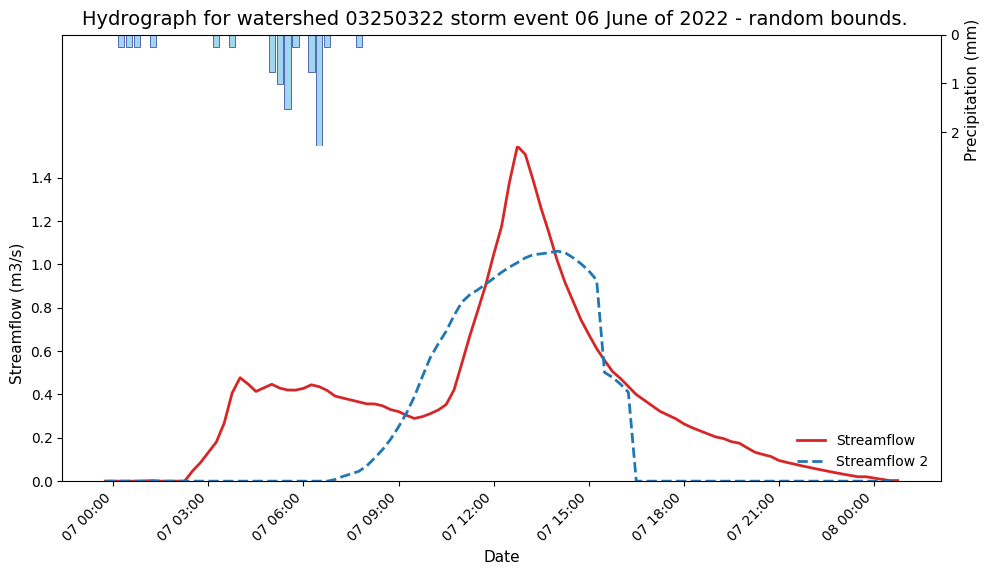

In [453]:
hydrograph2(
    df=df_hydrograph,
    streamflow_col='quickflow',
    streamflow2_col='simulated_flow',
    time_col='date',
    precip_col='ppt_mm',
    precip2_col='excess_precip',
    P_units='mm',
    S_units='m3/s',
    title=f"Hydrograph for watershed {sample_ws_id} storm event {event_str} - random bounds."
)

In [454]:
nonna = filtered_storm_events_metada.dropna(subset=['ppt_temporal_variability']).copy()
nonna.iloc[nonna['ppt_temporal_variability'].idxmin()]

event_start                 2018-03-01 02:15:00+00:00
event_end                   2018-03-05 18:00:00+00:00
month                                               3
ppt_start                   2018-03-01 02:45:00+00:00
ppt_end                     2018-03-01 12:00:00+00:00
total_precipitation_mm                       8.340637
total_ppt_after_peak_mm                           0.0
response_min                                     30.0
ppt_dutation_min                                  570
event_duration_min                               6720
peak_quickflow                             101.974672
ppt_temporal_variability                     0.000161
ppt_spatial_variability                      0.000014
n_ppt_stations                                      2
missing_streamflow                                  0
ppt_prior_14d                                0.022085
ppt_prior_7d                                 0.008541
ppt_prior_3d                                 0.001698
ppt_prior_24h               

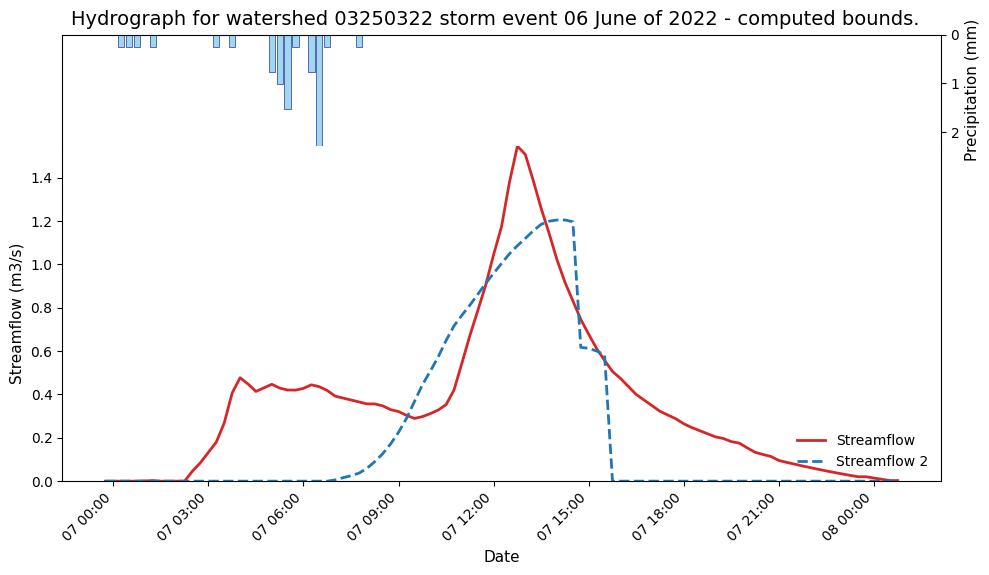

In [455]:
tc2 = optmized_params_computed_bounds['optimized_tc_hr']*3600
r2 = optmized_params_computed_bounds['optimized_r_hr']*3600
initial_loss2 = optmized_params_computed_bounds['optimized_initial_loss_mm']/1000
constant_loss_rate2 = (optmized_params_computed_bounds['optimized_constant_loss_mm_hr']/1000)/3600
sim_flow2, excess_ppt2 = model.simulate(tc=tc2, r=r2, initial_loss=initial_loss2, constant_loss_rate=constant_loss_rate2)

df_hydrograph2 = df.copy()
df_hydrograph2['simulated_flow'] = sim_flow2
df_hydrograph2['excess_precip'] = excess_ppt2
df_hydrograph2['date'] = df_hydrograph2.index
df_hydrograph2['ppt_mm'] = df_hydrograph2['height']*1000

event_str = df.index[0].strftime('%d %B of %Y')

hydrograph2(
    df=df_hydrograph2,
    streamflow_col='quickflow',
    streamflow2_col='simulated_flow',
    time_col='date',
    precip_col='ppt_mm',
    precip2_col='excess_precip',
    P_units='mm',
    S_units='m3/s',
    title=f"Hydrograph for watershed {sample_ws_id} storm event {event_str} - computed bounds."
)